# Inferência + Avaliação Out-of-Sample — Pacientes 28 e 72

Pipeline completo de inferência sem dependência de `.atr` para detecção.
O `.atr` é carregado **apenas ao final, para avaliação com ground truth**.

In [13]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import wfdb.processing as wp
import tensorflow as tf
import joblib
from pathlib import Path
from scipy.signal import butter, filtfilt, savgol_filter
from scipy.interpolate import interp1d
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from tensorflow.keras.preprocessing.sequence import pad_sequences

def bandpass(sig, fs, low=0.5, high=40):
    b, a = butter(3, [low / (fs / 2), high / (fs / 2)], btype='band')
    return filtfilt(b, a, sig)

def detect_wave_bounds(sig, peak, fs, search_pre=0.25, search_post=0.40, smooth_window=11):
    pre   = int(search_pre  * fs)
    post  = int(search_post * fs)
    left  = max(0, peak - pre)
    right = min(len(sig) - 1, peak + post)
    seg   = sig[left:right]
    if len(seg) < smooth_window + 2:
        return left, right
    dseg = savgol_filter(seg, smooth_window, 2, deriv=1)
    peak_local   = peak - left
    left_deriv   = np.abs(dseg[:peak_local])
    onset_local  = np.argmin(left_deriv) if len(left_deriv) > 0 else 0
    right_deriv  = np.abs(dseg[peak_local:])
    offset_local = peak_local + (np.argmin(right_deriv) if len(right_deriv) > 0 else 0)
    return left + onset_local, left + offset_local

## 1 — Configurações

In [14]:
DATA_DIR     = Path('data')
MODELS_DIR   = Path('models')
TARGET_LEN   = 200
WINDOW_SEC   = 10
OOS_PATIENTS = ['00', '01', '05', '07', '08', '17', '32']

## 2 — Carregar modelos e artefatos de treino

In [15]:
model2 = tf.keras.models.load_model(MODELS_DIR / 'clean_model2_morphology_final.keras')
model3 = tf.keras.models.load_model(MODELS_DIR / 'clean_model3_rhythm_final.keras')
le2    = joblib.load(MODELS_DIR / 'le2.pkl')

rr_params = json.load(open(MODELS_DIR / 'rr_params.json'))
RR_MEAN = rr_params['rr_mean']
RR_STD  = rr_params['rr_std']

print(f'model2 input : {model2.input_shape}')
print(f'model3 input : {model3.input_shape}')
print(f'Classes CNN  : {le2.classes_}')
print(f'RR_MEAN: {RR_MEAN:.4f}s | RR_STD: {RR_STD:.4f}s ({60/RR_MEAN:.1f} bpm)')

model2 input : (None, 200, 1)
model3 input : (None, 31, 2)
Classes CNN  : ['A' 'N' 'V']
RR_MEAN: 0.0541s | RR_STD: 138.8682s (1109.3 bpm)


## 3 — Detecção de picos QRS (XQRS — apenas .dat)

In [16]:
all_signals, all_fs, all_peaks = {}, {}, {}

for pid in OOS_PATIENTS:
    rec    = wfdb.rdrecord(str(DATA_DIR / pid))
    signal = rec.p_signal[:, 0]
    fs     = rec.fs

    xqrs = wp.XQRS(sig=signal, fs=fs)
    xqrs.detect()
    peaks = xqrs.qrs_inds

    all_signals[pid] = signal
    all_fs[pid]      = fs
    all_peaks[pid]   = peaks

    print(f'[{pid}] {len(peaks)} picos QRS | fs={fs}Hz | dur={len(signal)/fs/3600:.1f}h')

Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
[00] 105004 picos QRS | fs=128Hz | dur=21.0h
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
[01] 90538 picos QRS | fs=128Hz | dur=20.6h
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
[05] 112987 picos QRS | fs=128Hz | dur=24.3h
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
[07] 106725 picos QRS | fs=128Hz | dur=25.5h
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
[08] 108271 picos QRS | fs=128Hz | dur=25

## 4 — Segmentação dos batimentos

In [17]:
all_segs, all_meta = [], []

for pid in OOS_PATIENTS:
    signal = all_signals[pid]
    fs     = all_fs[pid]
    peaks  = all_peaks[pid]

    for peak in peaks:
        onset, offset = detect_wave_bounds(signal, peak, fs)
        seg = signal[onset:offset]
        if len(seg) < 10:
            continue
        x_orig = np.linspace(0, 1, len(seg))
        x_new  = np.linspace(0, 1, TARGET_LEN)
        all_segs.append(interp1d(x_orig, seg, kind='cubic')(x_new))
        all_meta.append({'peak': peak, 'patient': pid})

    print(f'[{pid}] {sum(1 for m in all_meta if m["patient"] == pid)} segmentos válidos')

segments = np.array(all_segs)
df_meta  = pd.DataFrame(all_meta)
print(f'Shape total: {segments.shape}')

[00] 104726 segmentos válidos
[01] 90453 segmentos válidos
[05] 112939 segmentos válidos
[07] 106437 segmentos válidos
[08] 108092 segmentos válidos
[17] 138322 segmentos válidos
[32] 90614 segmentos válidos
Shape total: (751583, 200)


## 5 — Classificação por batimento (Estágio 2 — CNN)

In [18]:
fs = list(all_fs.values())[0]

X_inf = np.array([bandpass(x, fs) for x in segments])
X_inf = (X_inf - X_inf.mean(axis=1, keepdims=True)) / (X_inf.std(axis=1, keepdims=True) + 1e-8)
X_inf = X_inf.reshape(-1, TARGET_LEN, 1)

pred_proba2  = model2.predict(X_inf, batch_size=512)
pred_enc     = np.argmax(pred_proba2, axis=1)
pred_labels  = le2.inverse_transform(pred_enc)

df_meta['pred_symbol'] = pred_labels
df_meta['pred_enc']    = pred_enc

for pid in OOS_PATIENTS:
    sub = df_meta[df_meta['patient'] == pid]
    print(f'[{pid}] Morfologia predita:')
    print(sub['pred_symbol'].value_counts().to_string())
    print()

1468/1468 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step
[00] Morfologia predita:
pred_symbol
N    100803
V      2451
A      1472

[01] Morfologia predita:
pred_symbol
N    88541
V     1068
A      844

[05] Morfologia predita:
pred_symbol
N    111908
A       808
V       223

[07] Morfologia predita:
pred_symbol
N    103374
V      2464
A       599

[08] Morfologia predita:
pred_symbol
N    106665
V      1118
A       309

[17] Morfologia predita:
pred_symbol
N    137902
V       277
A       143

[32] Morfologia predita:
pred_symbol
N    87879
V     2454
A      281



## 6 — Classificação por janela de 10s (Estágio 3 — BiLSTM)

In [19]:
results   = {}
win_meta  = {}

for pid in OOS_PATIENTS:
    sub = df_meta[df_meta['patient'] == pid].copy().reset_index(drop=True)
    fs  = all_fs[pid]

    sub['rr']        = sub['peak'].diff().fillna(0) / fs
    sub['window_id'] = (sub['peak'] // (WINDOW_SEC * fs)).astype(int)

    X_seq, win_ids, win_morph = [], [], []
    for wid, group in sub.groupby('window_id'):
        if len(group) < 3:
            continue
        symbol_enc = group['pred_symbol'].map({'N': 0, 'A': 1, 'V': 2}).values
        rr         = group['rr'].values
        X_seq.append(np.stack([symbol_enc, rr], axis=1))
        win_ids.append(wid)
        win_morph.append(group['pred_symbol'].mode()[0])

    MAX_BEATS = max(len(s) for s in X_seq)
    X_pad = pad_sequences(X_seq, maxlen=MAX_BEATS, dtype='float32', padding='post', value=0.0)
    X_pad[:, :, 1] = (X_pad[:, :, 1] - RR_MEAN) / (RR_STD + 1e-8)

    proba = model3.predict(X_pad, batch_size=64).flatten()
    preds = (proba >= 0.5).astype(int)

    df_win = pd.DataFrame({
        'window_id':    win_ids,
        'pred_class':   preds,
        'proba_anorm':  proba,
        'pred_label':   ['Anormal' if p else 'Normal' for p in preds],
        'dominant_morph': win_morph,
    })
    results[pid]  = df_win
    win_meta[pid] = {'MAX_BEATS': MAX_BEATS}

    n_abn = (preds == 1).sum()
    print(f'[{pid}] {len(preds)} janelas | Normal: {(preds==0).sum()} | Anormal: {n_abn} ({100*n_abn/len(preds):.1f}%)')

115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
[00] 7308 janelas | Normal: 5705 | Anormal: 1603 (21.9%)
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
[01] 7400 janelas | Normal: 593 | Anormal: 6807 (92.0%)
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
[05] 8693 janelas | Normal: 1029 | Anormal: 7664 (88.2%)
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
[07] 8544 janelas | Normal: 5048 | Anormal: 3496 (40.9%)
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
[08] 8705 janelas | Normal: 7571 | Anormal: 1134 (13.0%)
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
[17] 8838 janelas | Normal: 122 | Anormal: 8716 (98.6%)
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
[32] 7368 janelas | Normal: 5724 | Anormal: 1644 (22.3%)


## 7 — Ground truth via .atr (apenas para avaliação)

In [20]:
# O .atr é lido SOMENTE aqui para gerar ground truth de avaliação.
# Não afeta nenhuma etapa do pipeline de detecção ou classificação.

gt_beat  = {}   # ground truth por batimento
gt_rhythm = {}  # ground truth de ritmo por sample

for pid in OOS_PATIENTS:
    ann    = wfdb.rdann(str(DATA_DIR / pid), 'atr')
    signal = all_signals[pid]
    fs     = all_fs[pid]

    # Ground truth de morfologia por batimento
    ann_mask    = np.isin(ann.symbol, ['N', 'A', 'V'])
    ann_samples = ann.sample[ann_mask]
    ann_symbols = np.array(ann.symbol)[ann_mask]
    gt_beat[pid] = (ann_samples, ann_symbols)

    # Ground truth de ritmo por janela (propaga por tempo)
    ann_rhythm = pd.DataFrame({'sample': ann.sample, 'aux_note': ann.aux_note})
    ann_rhythm = ann_rhythm[ann_rhythm['aux_note'].str.strip().str.startswith('(')]
    ann_rhythm = ann_rhythm.sort_values('sample').drop_duplicates(subset='sample').reset_index(drop=True)

    bins   = [-1] + list(ann_rhythm['sample']) + [len(signal)]
    labels = [''] + list(ann_rhythm['aux_note'])

    df_win = results[pid].copy()
    win_center = (df_win['window_id'] * WINDOW_SEC * fs + WINDOW_SEC * fs / 2).astype(int)
    df_win['true_rhythm'] = pd.cut(win_center, bins=bins, labels=labels, ordered=False).astype(str)

    # Ground truth de janela: Normal se ritmo (N, Anormal caso contrário
    df_win['true_class'] = (df_win['true_rhythm'] != '(N').astype(int)
    results[pid] = df_win

    print(f'[{pid}] Ritmos no .atr: {ann_rhythm["aux_note"].value_counts().to_dict()}')

[00] Ritmos no .atr: {'(AFIB': 44, '(VT': 40, '(N': 5}
[01] Ritmos no .atr: {'(N': 457, '(AB': 293, '(SBR': 83, '(AFIB': 53, '(SVTA': 25, '(B': 16, '(T': 6}
[05] Ritmos no .atr: {'(N': 14, '(AB': 8, '(AFIB': 3, '(SVTA': 2}
[07] Ritmos no .atr: {'(N': 499, '(B': 416, '(AB': 51, '(SVTA': 28, '(AFIB': 8, '(T': 1}
[08] Ritmos no .atr: {'(N': 20, '(SVTA': 13, '(AFIB': 4, '(B': 1, '(AB': 1}
[17] Ritmos no .atr: {'(AFIB': 1}
[32] Ritmos no .atr: {'(N': 541, '(AFIB': 361, '(AB': 174, '(SVTA': 28, '(VT': 2}


## 8 — Avaliação: Morfologia por batimento (Estágio 2)


=== Paciente 00 — Morfologia (Estágio 2) ===
              precision    recall  f1-score   support

           N       1.00      0.96      0.98     73956
           A       0.00      0.03      0.00        36
           V       0.03      0.28      0.05       153

    accuracy                           0.96     74145
   macro avg       0.34      0.42      0.35     74145
weighted avg       1.00      0.96      0.98     74145



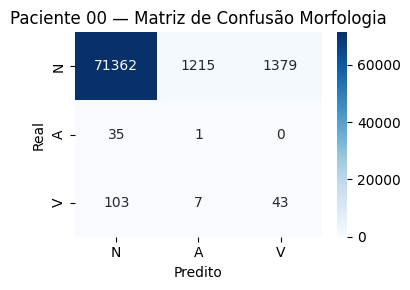


=== Paciente 01 — Morfologia (Estágio 2) ===
              precision    recall  f1-score   support

           N       0.94      0.98      0.96     84795
           A       0.05      0.01      0.01      4974
           V       0.20      0.37      0.26       568

    accuracy                           0.92     90337
   macro avg       0.40      0.45      0.41     90337
weighted avg       0.89      0.92      0.90     90337



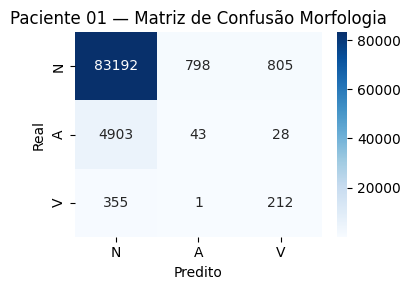


=== Paciente 05 — Morfologia (Estágio 2) ===
              precision    recall  f1-score   support

           N       0.98      0.99      0.99    110383
           A       0.10      0.04      0.06      1987
           V       0.01      0.33      0.01         3

    accuracy                           0.98    112373
   macro avg       0.36      0.46      0.35    112373
weighted avg       0.97      0.98      0.97    112373



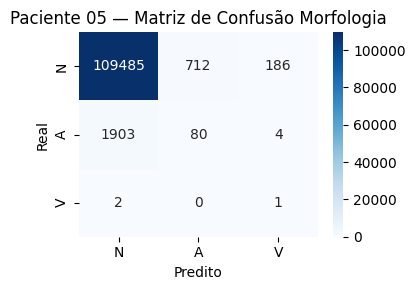


=== Paciente 07 — Morfologia (Estágio 2) ===
              precision    recall  f1-score   support

           N       0.97      0.99      0.98    100371
           A       0.00      0.00      0.00      1192
           V       0.97      0.54      0.69      3786

    accuracy                           0.97    105349
   macro avg       0.65      0.51      0.56    105349
weighted avg       0.96      0.97      0.96    105349



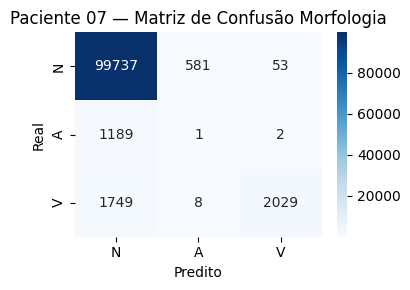


=== Paciente 08 — Morfologia (Estágio 2) ===
              precision    recall  f1-score   support

           N       0.99      0.99      0.99     97275
           A       0.16      0.02      0.04      1161
           V       0.05      0.26      0.08       163

    accuracy                           0.98     98599
   macro avg       0.40      0.42      0.37     98599
weighted avg       0.98      0.98      0.98     98599



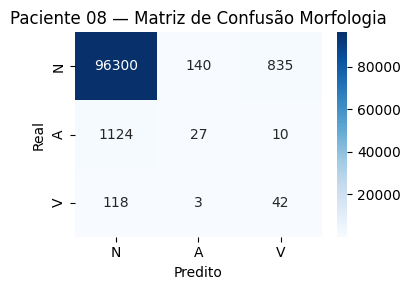


=== Paciente 17 — Morfologia (Estágio 2) ===
              precision    recall  f1-score   support

           N       1.00      1.00      1.00    137260
           A       0.00      0.00      0.00         0
           V       0.11      0.61      0.19        31

    accuracy                           1.00    137291
   macro avg       0.37      0.54      0.40    137291
weighted avg       1.00      1.00      1.00    137291



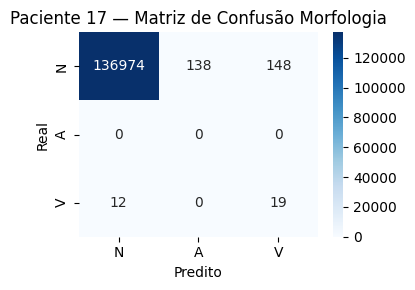


=== Paciente 32 — Morfologia (Estágio 2) ===
              precision    recall  f1-score   support

           N       0.97      0.97      0.97     85659
           A       0.03      0.00      0.01      2534
           V       0.01      0.28      0.03       121

    accuracy                           0.95     88314
   macro avg       0.34      0.42      0.34     88314
weighted avg       0.94      0.95      0.94     88314



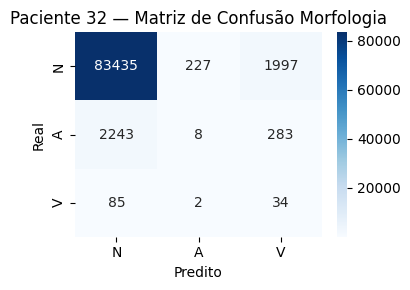

In [21]:
tol = int(0.05 * list(all_fs.values())[0])  # 50ms

for pid in OOS_PATIENTS:
    ann_samples, ann_symbols = gt_beat[pid]
    sub = df_meta[df_meta['patient'] == pid].copy()

    # Para cada batimento predito, busca ground truth mais próximo
    y_true_beat, y_pred_beat = [], []
    for _, row in sub.iterrows():
        diffs = np.abs(ann_samples - row['peak'])
        idx   = np.argmin(diffs)
        if diffs[idx] <= tol:
            y_true_beat.append(ann_symbols[idx])
            y_pred_beat.append(row['pred_symbol'])

    y_true_beat = np.array(y_true_beat)
    y_pred_beat = np.array(y_pred_beat)
    classes     = ['N', 'A', 'V']

    print(f'\n=== Paciente {pid} — Morfologia (Estágio 2) ===')
    print(classification_report(y_true_beat, y_pred_beat, labels=classes, zero_division=0))

    cm = confusion_matrix(y_true_beat, y_pred_beat, labels=classes)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes,
                cmap='Blues', ax=ax)
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')
    ax.set_title(f'Paciente {pid} — Matriz de Confusão Morfologia')
    plt.tight_layout(); plt.show()

## 9 — Avaliação: Ritmo por janela (Estágio 3)


=== Paciente 00 — Ritmo (Estágio 3) ===
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94      6428
     Anormal       0.55      1.00      0.71       880

    accuracy                           0.90      7308
   macro avg       0.77      0.94      0.82      7308
weighted avg       0.95      0.90      0.91      7308



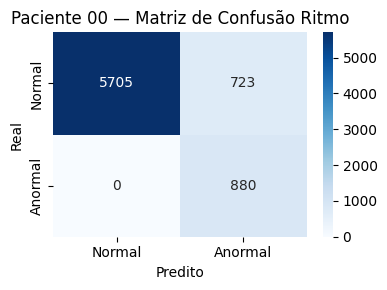

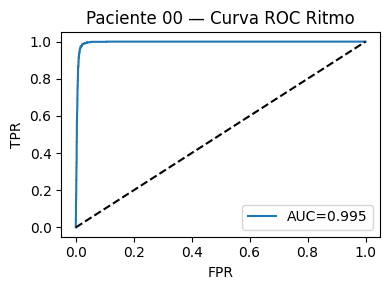

AUC: 0.9949

=== Paciente 01 — Ritmo (Estágio 3) ===
              precision    recall  f1-score   support

      Normal       0.13      0.06      0.08      1290
     Anormal       0.82      0.92      0.87      6110

    accuracy                           0.77      7400
   macro avg       0.48      0.49      0.48      7400
weighted avg       0.70      0.77      0.73      7400



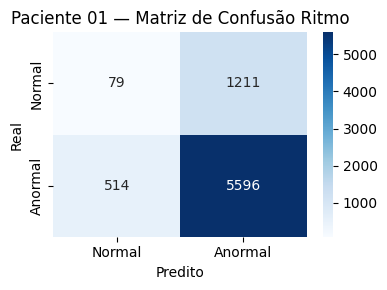

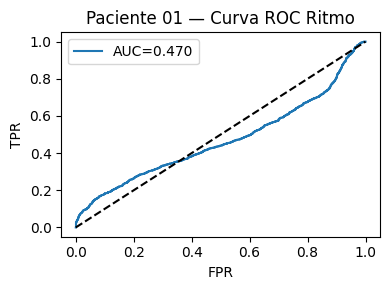

AUC: 0.4698

=== Paciente 05 — Ritmo (Estágio 3) ===
              precision    recall  f1-score   support

      Normal       1.00      0.12      0.21      8685
     Anormal       0.00      1.00      0.00         8

    accuracy                           0.12      8693
   macro avg       0.50      0.56      0.11      8693
weighted avg       1.00      0.12      0.21      8693



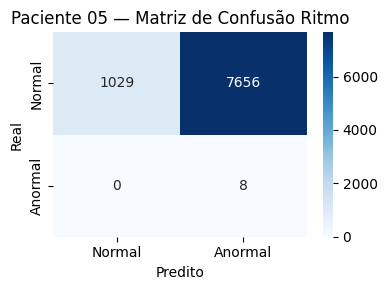

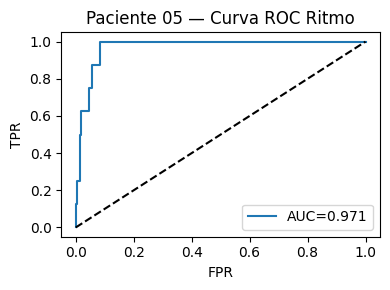

AUC: 0.9708

=== Paciente 07 — Ritmo (Estágio 3) ===
              precision    recall  f1-score   support

      Normal       1.00      0.71      0.83      7058
     Anormal       0.42      0.99      0.59      1486

    accuracy                           0.76      8544
   macro avg       0.71      0.85      0.71      8544
weighted avg       0.90      0.76      0.79      8544



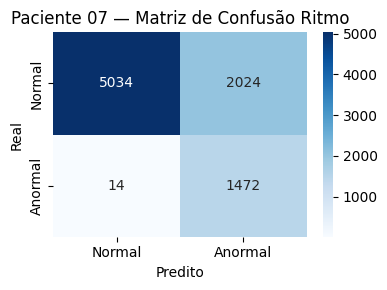

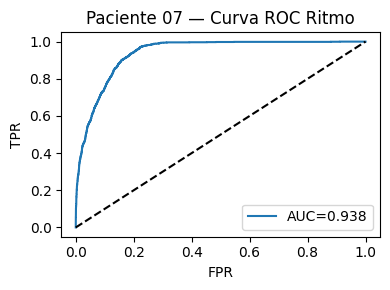

AUC: 0.9378

=== Paciente 08 — Ritmo (Estágio 3) ===
              precision    recall  f1-score   support

      Normal       1.00      0.87      0.93      8693
     Anormal       0.01      1.00      0.02        12

    accuracy                           0.87      8705
   macro avg       0.51      0.94      0.48      8705
weighted avg       1.00      0.87      0.93      8705



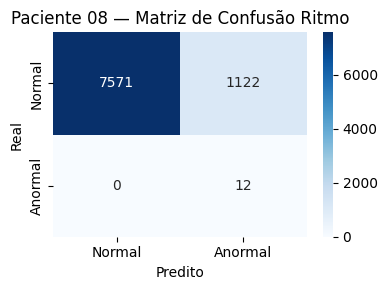

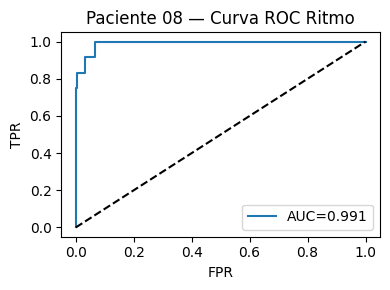

AUC: 0.9910

=== Paciente 17 — Ritmo (Estágio 3) ===
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         0
     Anormal       1.00      0.99      0.99      8838

    accuracy                           0.99      8838
   macro avg       0.50      0.49      0.50      8838
weighted avg       1.00      0.99      0.99      8838



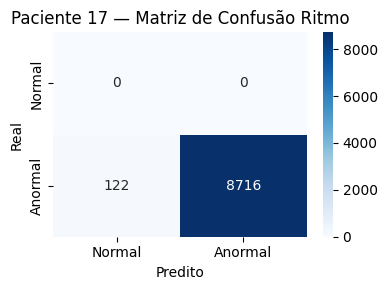


=== Paciente 32 — Ritmo (Estágio 3) ===
              precision    recall  f1-score   support

      Normal       1.00      0.81      0.90      7029
     Anormal       0.21      1.00      0.34       339

    accuracy                           0.82      7368
   macro avg       0.60      0.91      0.62      7368
weighted avg       0.96      0.82      0.87      7368



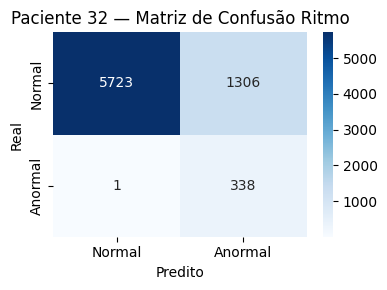

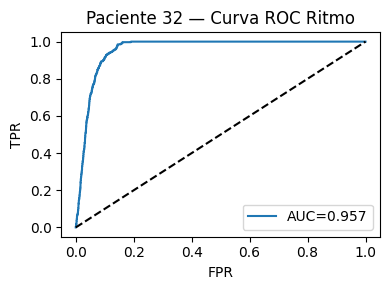

AUC: 0.9568


In [22]:
for pid in OOS_PATIENTS:
    df_win = results[pid].dropna(subset=['true_class']).copy()
    y_true = df_win['true_class'].astype(int).values
    y_pred = df_win['pred_class'].values
    y_prob = df_win['proba_anorm'].values

    print(f'\n=== Paciente {pid} — Ritmo (Estágio 3) ===')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Anormal'], zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=['Normal', 'Anormal'],
                yticklabels=['Normal', 'Anormal'],
                cmap='Blues', ax=ax)
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')
    ax.set_title(f'Paciente {pid} — Matriz de Confusão Ritmo')
    plt.tight_layout(); plt.show()

    # Curva ROC
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_prob)
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.figure(figsize=(4, 3))
        plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel('FPR'); plt.ylabel('TPR')
        plt.title(f'Paciente {pid} — Curva ROC Ritmo')
        plt.legend(); plt.tight_layout(); plt.show()
        print(f'AUC: {auc:.4f}')

## 10 — Acurácia por Morfologia × Ritmo (heatmap)

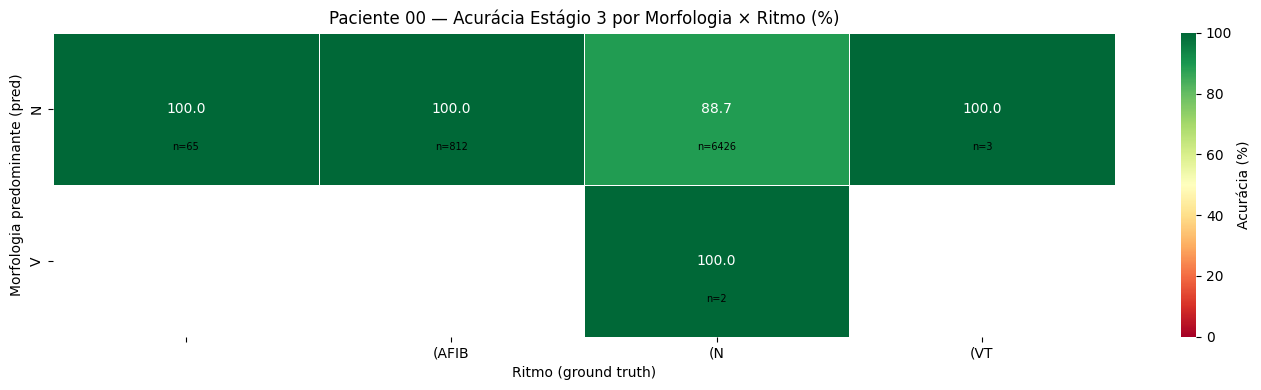

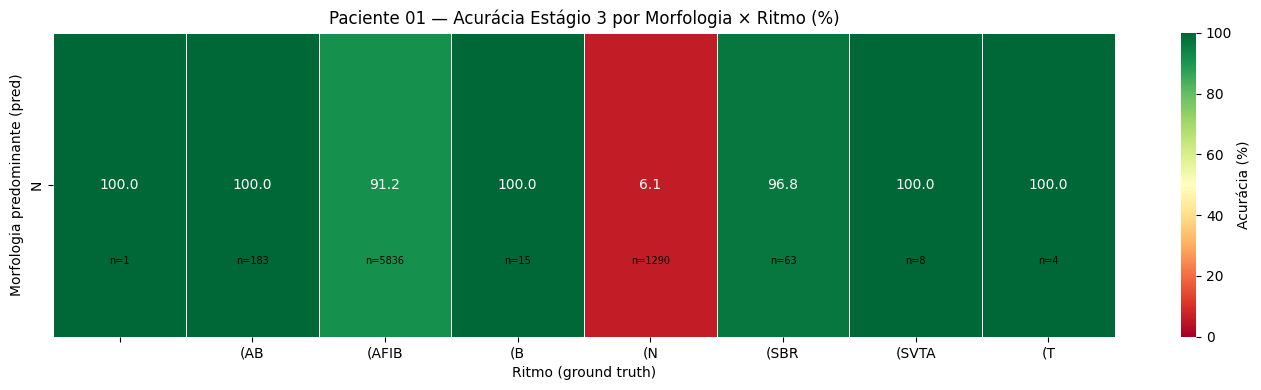

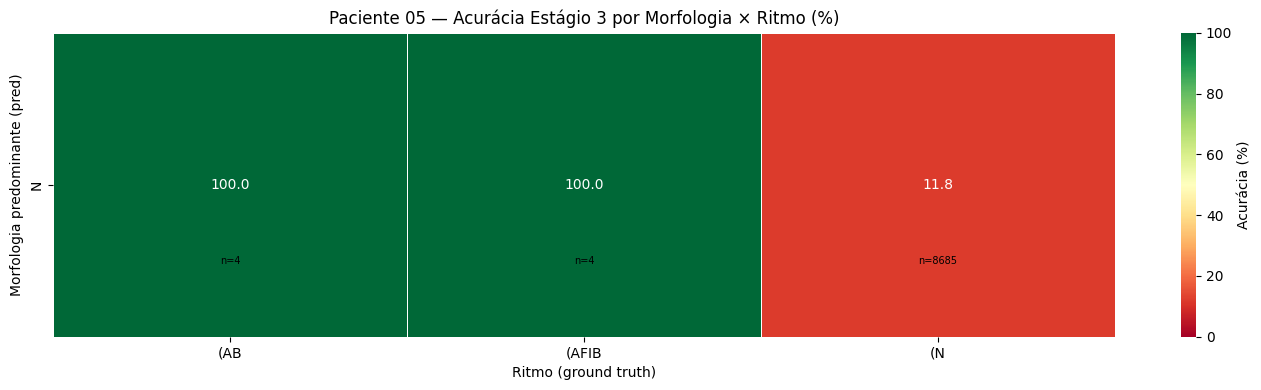

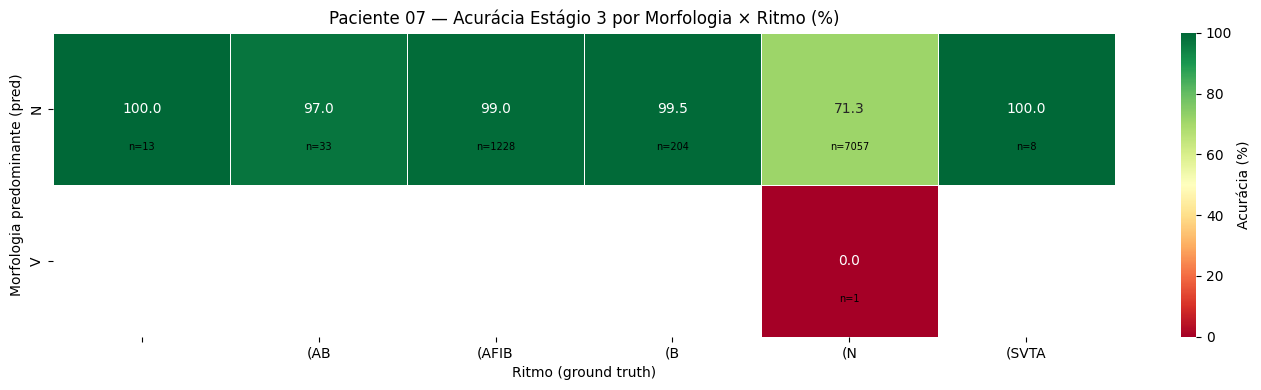

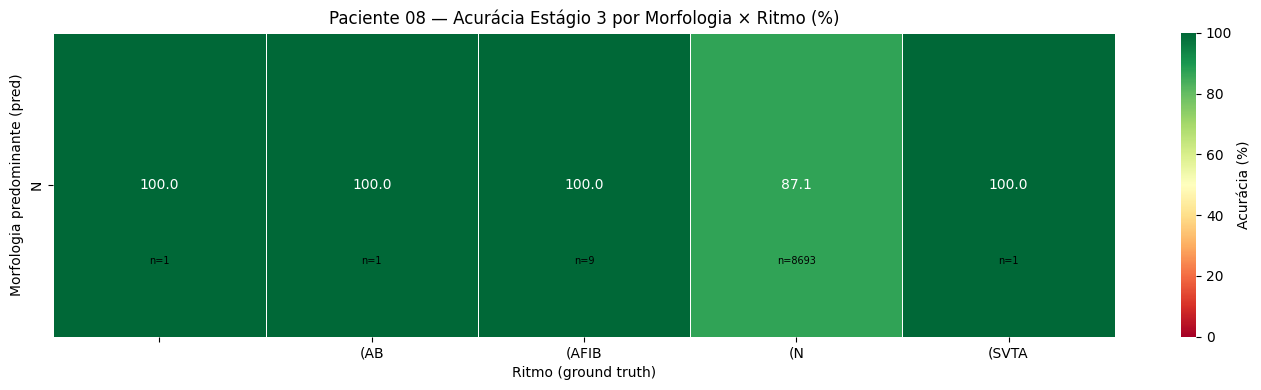

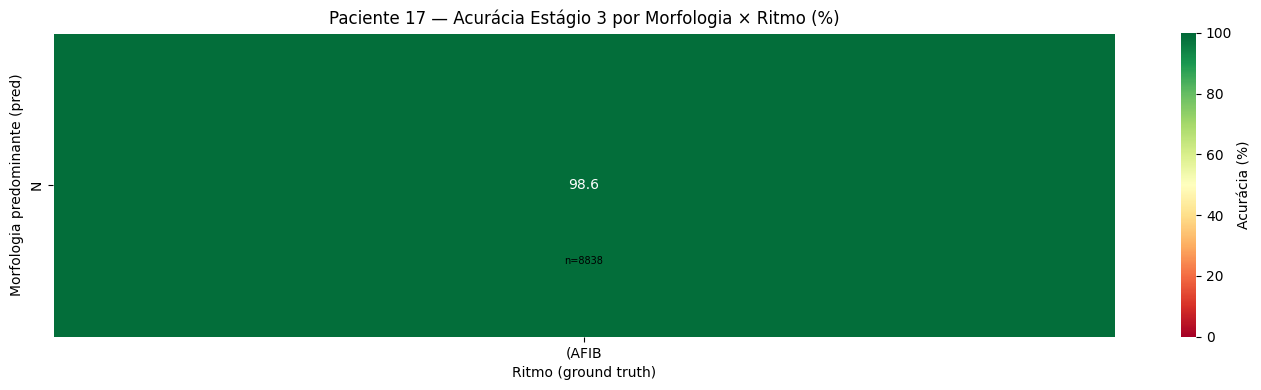

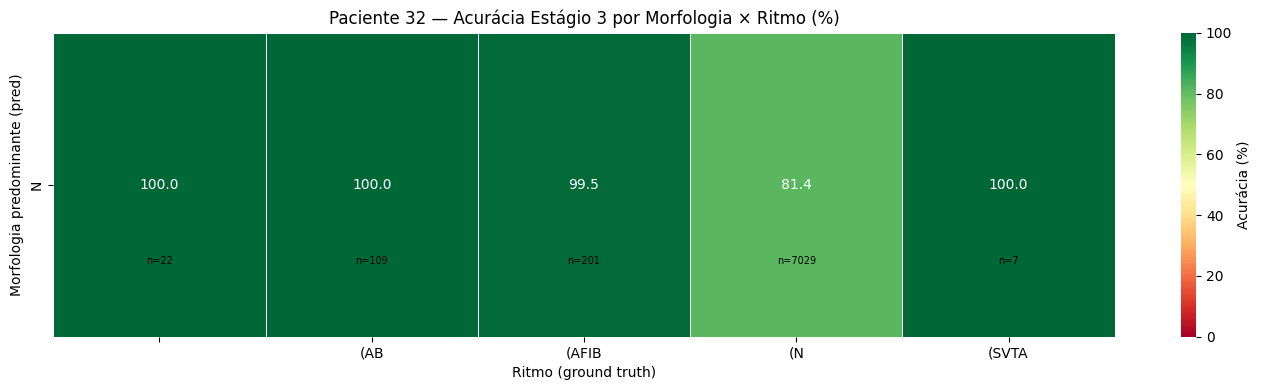

In [23]:
for pid in OOS_PATIENTS:
    df_win = results[pid].dropna(subset=['true_class']).copy()
    df_win['correct'] = (df_win['true_class'].astype(int) == df_win['pred_class']).astype(int)

    pivot = df_win.groupby(['dominant_morph', 'true_rhythm'])['correct'].agg(['mean','count']).reset_index()
    pivot['mean'] = (pivot['mean'] * 100).round(1)

    acc_mat   = pivot.pivot(index='dominant_morph', columns='true_rhythm', values='mean')
    count_mat = pivot.pivot(index='dominant_morph', columns='true_rhythm', values='count')

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(acc_mat, annot=True, fmt='.1f', cmap='RdYlGn',
                vmin=0, vmax=100, ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Acurácia (%)'})
    for i in range(acc_mat.shape[0]):
        for j in range(acc_mat.shape[1]):
            val = count_mat.iloc[i, j]
            if not np.isnan(val):
                ax.text(j + 0.5, i + 0.75, f'n={int(val)}',
                        ha='center', va='center', fontsize=7, color='black')
    ax.set_title(f'Paciente {pid} — Acurácia Estágio 3 por Morfologia × Ritmo (%)')
    ax.set_xlabel('Ritmo (ground truth)'); ax.set_ylabel('Morfologia predominante (pred)')
    plt.tight_layout(); plt.show()

## 11 — Timeline de probabilidade por janela

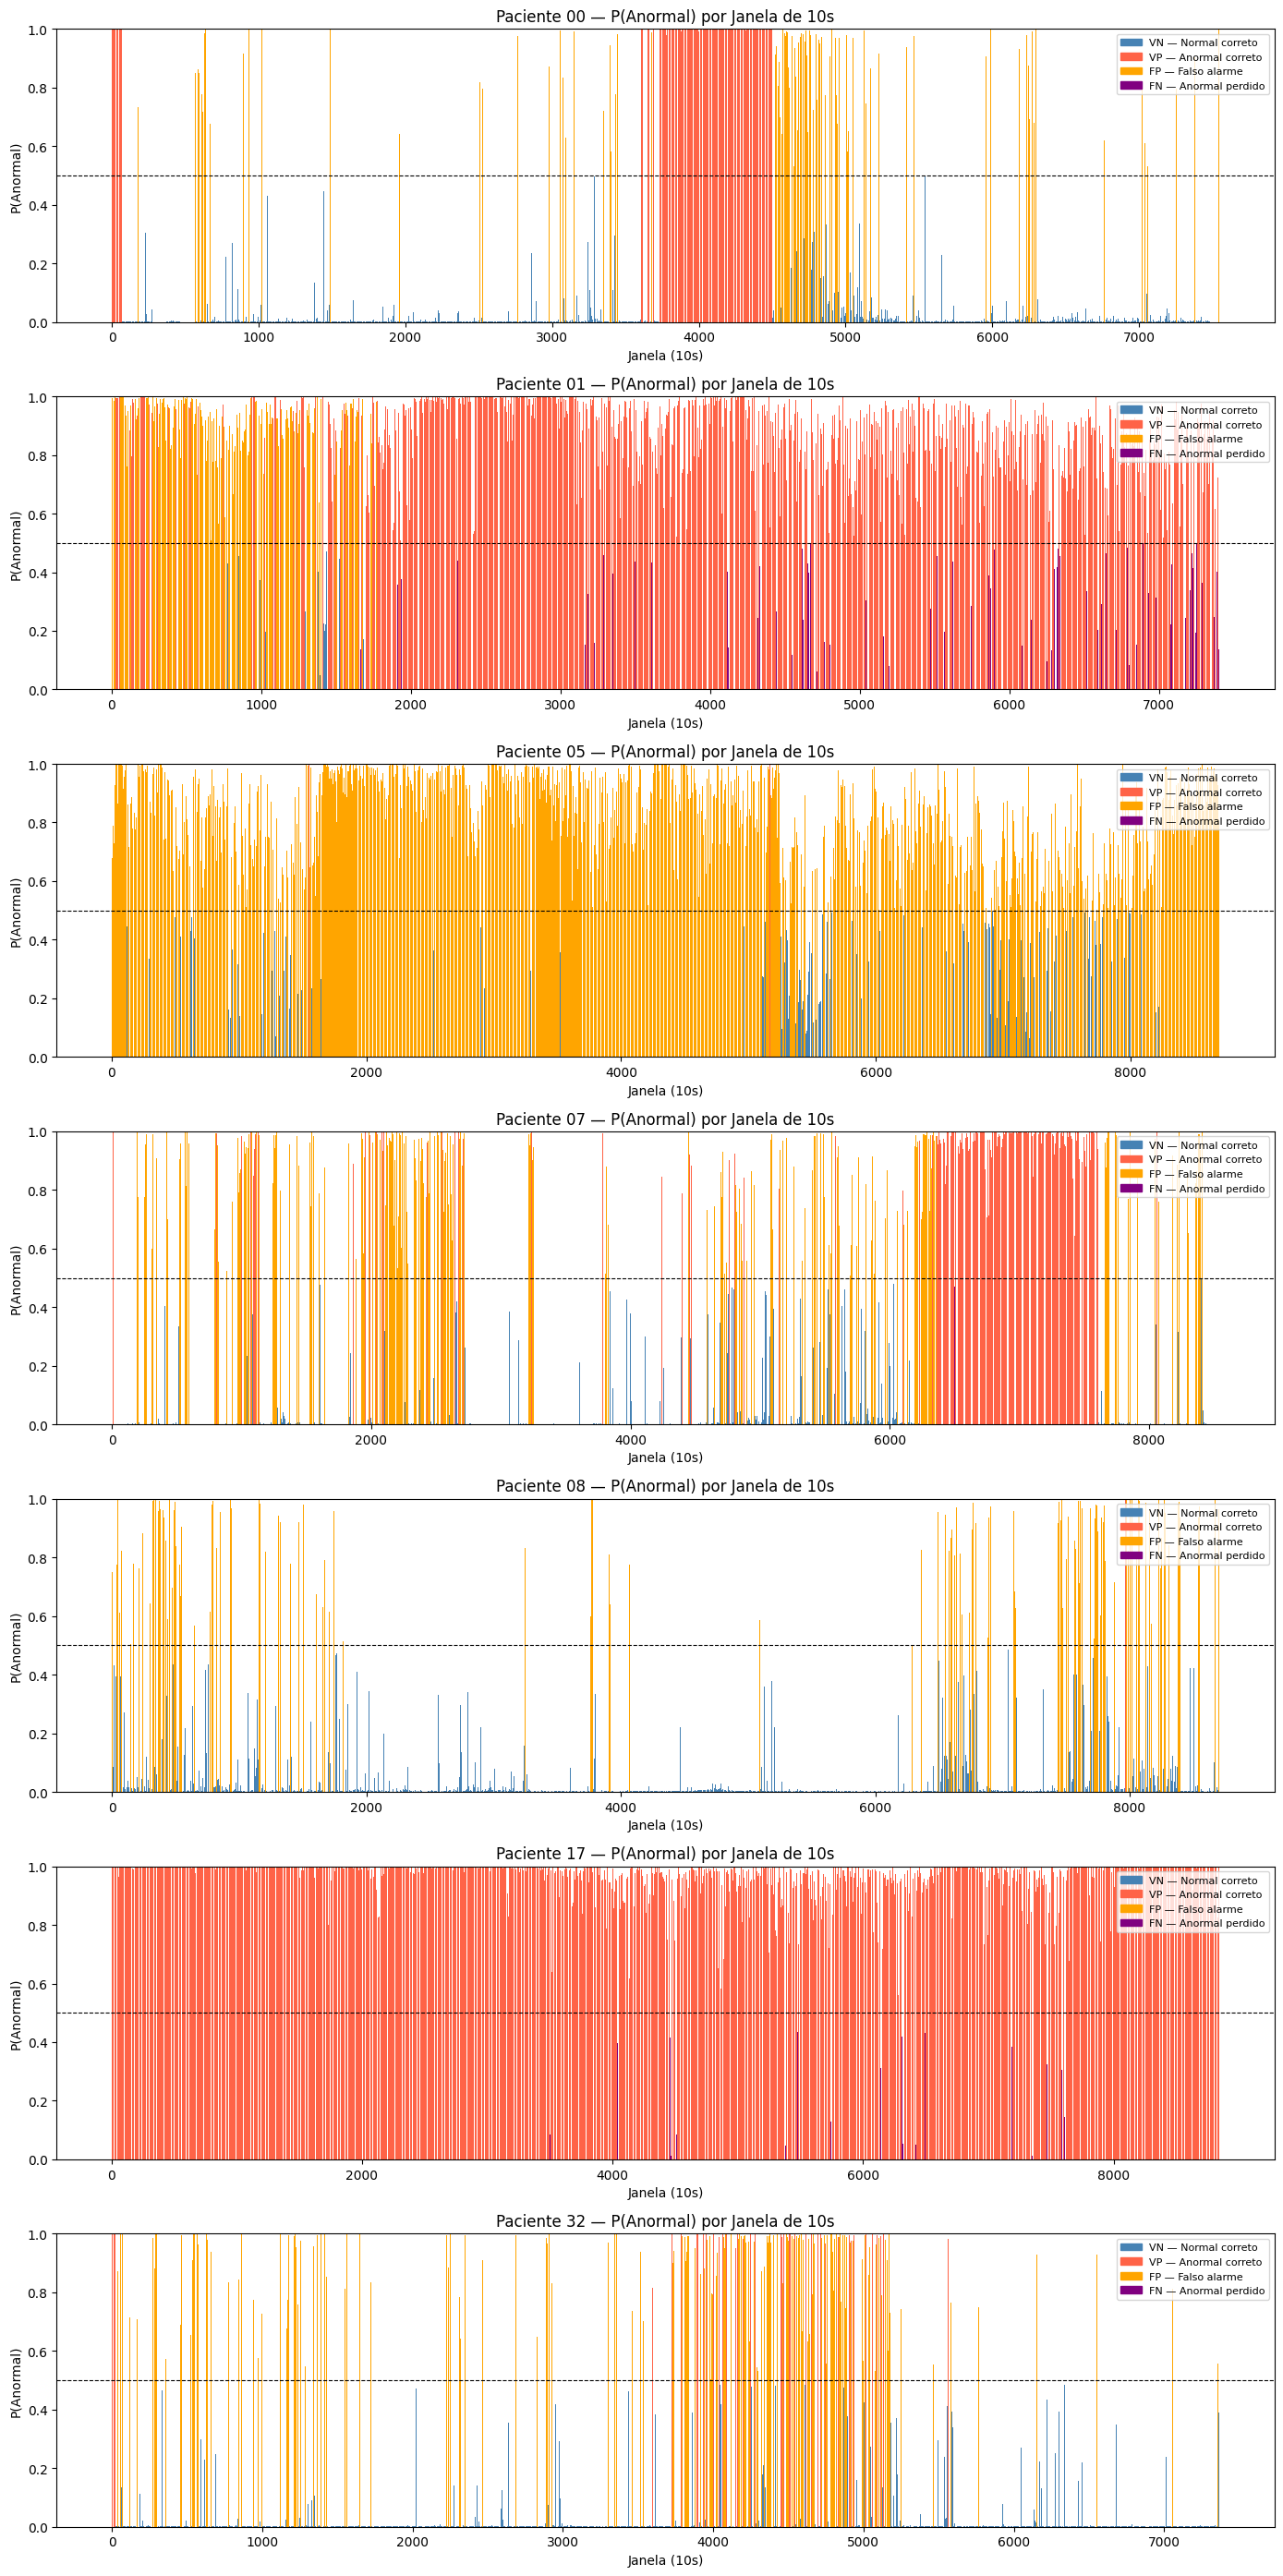

In [24]:
fig, axes = plt.subplots(len(OOS_PATIENTS), 1, figsize=(14, 4 * len(OOS_PATIENTS)))
if len(OOS_PATIENTS) == 1: axes = [axes]

for ax, pid in zip(axes, OOS_PATIENTS):
    df_win = results[pid].dropna(subset=['true_class']).copy()
    colors = []
    for _, row in df_win.iterrows():
        if row['pred_class'] == 1 and row['true_class'] == 1:
            colors.append('tomato')        # VP — anormal correto
        elif row['pred_class'] == 0 and row['true_class'] == 0:
            colors.append('steelblue')     # VN — normal correto
        elif row['pred_class'] == 1 and row['true_class'] == 0:
            colors.append('orange')        # FP — falso alarme
        else:
            colors.append('purple')        # FN — anormal perdido

    ax.bar(df_win['window_id'], df_win['proba_anorm'], color=colors, width=0.8)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8)
    ax.set_ylim(0, 1)
    ax.set_title(f'Paciente {pid} — P(Anormal) por Janela de 10s')
    ax.set_xlabel('Janela (10s)'); ax.set_ylabel('P(Anormal)')
    ax.legend(handles=[
        plt.Rectangle((0,0),1,1, color='steelblue', label='VN — Normal correto'),
        plt.Rectangle((0,0),1,1, color='tomato',    label='VP — Anormal correto'),
        plt.Rectangle((0,0),1,1, color='orange',    label='FP — Falso alarme'),
        plt.Rectangle((0,0),1,1, color='purple',    label='FN — Anormal perdido'),
    ], loc='upper right', fontsize=8)

plt.tight_layout(); plt.show()

## 12 — Resumo consolidado

In [25]:
for pid in OOS_PATIENTS:
    df_win = results[pid].dropna(subset=['true_class']).copy()
    sub    = df_meta[df_meta['patient'] == pid]
    y_true = df_win['true_class'].astype(int).values
    y_pred = df_win['pred_class'].values

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,0)

    sens = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    spec = tn / (tn + fp) if (tn + fp) > 0 else float('nan')
    auc  = roc_auc_score(y_true, df_win['proba_anorm'].values) if len(np.unique(y_true)) > 1 else float('nan')

    print(f'Paciente {pid}')
    print(f'  Batimentos segmentados : {len(sub)}')
    print(f'  Morfologia predita     : {sub["pred_symbol"].value_counts().to_dict()}')
    print(f'  Janelas avaliadas      : {len(df_win)}')
    print(f'  Sensitivity            : {sens:.3f}')
    print(f'  Specificity            : {spec:.3f}')
    print(f'  AUC                    : {auc:.3f}')
    print()

Paciente 00
  Batimentos segmentados : 104726
  Morfologia predita     : {'N': 100803, 'V': 2451, 'A': 1472}
  Janelas avaliadas      : 7308
  Sensitivity            : 1.000
  Specificity            : 0.888
  AUC                    : 0.995

Paciente 01
  Batimentos segmentados : 90453
  Morfologia predita     : {'N': 88541, 'V': 1068, 'A': 844}
  Janelas avaliadas      : 7400
  Sensitivity            : 0.916
  Specificity            : 0.061
  AUC                    : 0.470

Paciente 05
  Batimentos segmentados : 112939
  Morfologia predita     : {'N': 111908, 'A': 808, 'V': 223}
  Janelas avaliadas      : 8693
  Sensitivity            : 1.000
  Specificity            : 0.118
  AUC                    : 0.971

Paciente 07
  Batimentos segmentados : 106437
  Morfologia predita     : {'N': 103374, 'V': 2464, 'A': 599}
  Janelas avaliadas      : 8544
  Sensitivity            : 0.991
  Specificity            : 0.713
  AUC                    : 0.938

Paciente 08
  Batimentos segmentados : 108

## 13 — Frequência Cardíaca (bpm) × Acurácia

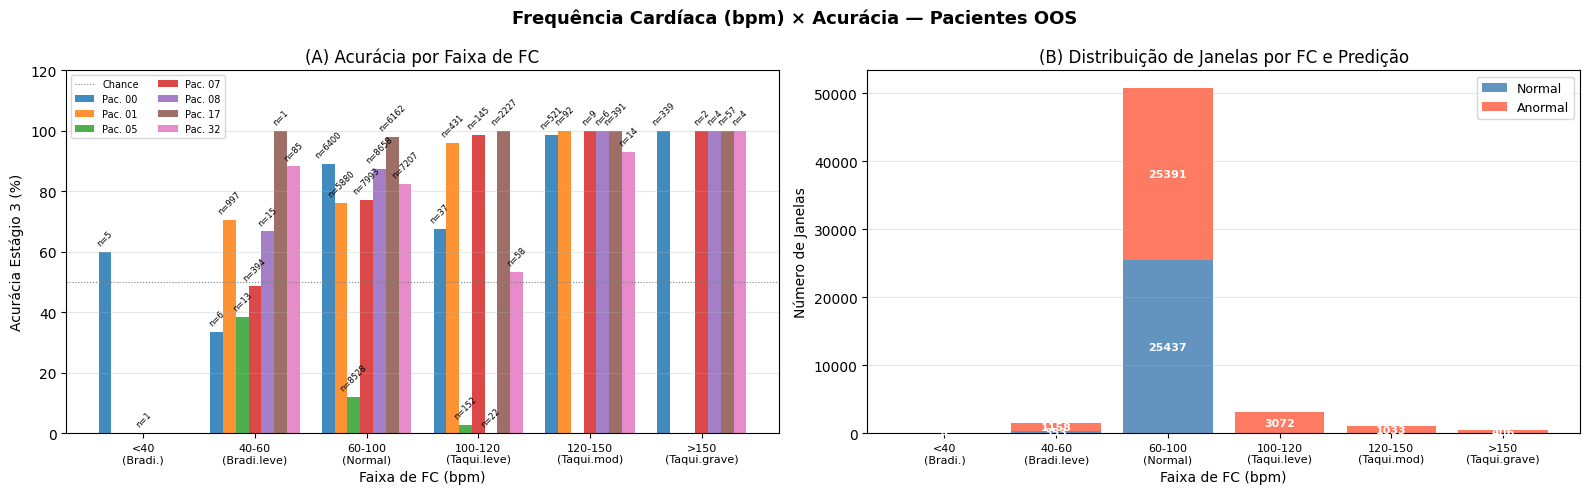

In [29]:
# ── Célula 13 — Frequência Cardíaca (bpm) × Acurácia por Faixa ──────────────
FC_BINS   = [0, 40, 60, 100, 120, 150, 300]
FC_LABELS = ['<40\n(Bradi.)', '40-60\n(Bradi.leve)', '60-100\n(Normal)',
             '100-120\n(Taqui.leve)', '120-150\n(Taqui.mod)', '>150\n(Taqui.grave)']

rows_all = []

for pid in OOS_PATIENTS:
    fs_    = all_fs[pid]
    sub    = df_meta[df_meta['patient'] == pid].copy()
    df_win = results[pid].dropna(subset=['true_class']).copy().reset_index(drop=True)
    df_win['correct'] = (df_win['true_class'].astype(int) == df_win['pred_class']).astype(int)

    sub['rr']        = sub['peak'].diff().fillna(0) / fs_
    sub['window_id'] = (sub['peak'] // (WINDOW_SEC * fs_)).astype(int)

    rr_valid = sub[sub['rr'] > 0.3]
    fc_win   = (rr_valid.groupby('window_id')['rr']
                        .mean()
                        .apply(lambda rr: 60 / rr)
                        .reset_index())
    fc_win.columns = ['window_id', 'fc_mean_bpm']
    fc_win['window_id'] = fc_win['window_id'].astype(int)

    df_win['window_id'] = df_win['window_id'].astype(int)
    df_win = df_win.merge(fc_win, on='window_id', how='left')
    df_win = df_win.dropna(subset=['fc_mean_bpm'])

    df_win['fc_bin'] = pd.cut(df_win['fc_mean_bpm'], bins=FC_BINS, labels=FC_LABELS, right=False)
    df_win['patient'] = pid
    rows_all.append(df_win)

df_all = pd.concat(rows_all, ignore_index=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Frequência Cardíaca (bpm) × Acurácia — Pacientes OOS', fontsize=13, fontweight='bold')

# (A) Acurácia média por faixa de FC
ax = axes[0]
palette_pid = {pid: c for pid, c in zip(OOS_PATIENTS, plt.cm.tab10.colors)}

agg = (df_all.groupby(['fc_bin', 'patient'], observed=True)['correct']
             .agg(['mean', 'count']).reset_index())
agg['acc_pct'] = (agg['mean'] * 100).round(1)

bins_present = [b for b in FC_LABELS if b in agg['fc_bin'].values]
x = np.arange(len(bins_present))
patients = list(dict.fromkeys(df_all['patient'].tolist()))
width = 0.8 / len(patients)

for i, pid in enumerate(patients):
    sub_agg = (agg[agg['patient'] == pid]
               .set_index('fc_bin')
               .reindex(bins_present))
    bars = ax.bar(x + (i - len(patients)/2 + 0.5) * width,
                  sub_agg['acc_pct'].fillna(0),
                  width=width, label=f'Pac. {pid}',
                  color=palette_pid[pid], alpha=0.85)
    for bar, (_, row) in zip(bars, sub_agg.iterrows()):
        if pd.notna(row['count']) and row['count'] > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5,
                    f'n={int(row["count"])}',
                    ha='center', va='bottom', fontsize=6, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(bins_present, fontsize=8)
ax.set_ylim(0, 120)
ax.set_ylabel('Acurácia Estágio 3 (%)')
ax.set_xlabel('Faixa de FC (bpm)')
ax.set_title('(A) Acurácia por Faixa de FC')
ax.axhline(50, color='grey', linestyle=':', linewidth=0.8, label='Chance')
ax.legend(fontsize=7, ncol=2)
ax.grid(axis='y', alpha=0.3)

# (B) Distribuição de janelas empilhada
ax2 = axes[1]
counts = (df_all.groupby(['fc_bin', 'pred_label'], observed=True)
                .size().unstack(fill_value=0))

for col in ['Normal', 'Anormal']:
    if col not in counts.columns:
        counts[col] = 0

counts = counts.reindex(FC_LABELS)
bottom = np.zeros(len(counts))
colors_map = {'Normal': 'steelblue', 'Anormal': 'tomato'}

for label in ['Normal', 'Anormal']:
    vals = counts[label].values.astype(float)
    ax2.bar(range(len(counts)), vals, bottom=bottom,
            label=label, color=colors_map[label], alpha=0.85)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 3:
            ax2.text(j, b + v / 2, str(int(v)), ha='center', va='center',
                     fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax2.set_xticks(range(len(counts)))
ax2.set_xticklabels(FC_LABELS, fontsize=8)
ax2.set_ylabel('Número de Janelas')
ax2.set_xlabel('Faixa de FC (bpm)')
ax2.set_title('(B) Distribuição de Janelas por FC e Predição')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()